<a href="https://www.kaggle.com/code/shravankumarpandey/shared-subgraph?scriptVersionId=336722211" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Shared SubGraph In LangGraph

In [4]:
pip install langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GROQ_API_KEY")

In [7]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

llm=ChatGroq(model="llama-3.1-8b-instant",groq_api_key=secret_value_0)

class ParentState(TypedDict):
    question:str
    eng_answer:str
    hin_answer:str


def generate_hindi(state:ParentState)->ParentState:
    prompt=f"""
    Generate the following text into hindi 
    {state["eng_answer"]}
    and do not add extra thing into it
"""
    hindi_text=llm.invoke(prompt).content
    return {"hin_answer":hindi_text}

substate=StateGraph(ParentState)
substate.add_node("generate_hindi",generate_hindi)
substate.add_edge(START,"generate_hindi")
substate.add_edge("generate_hindi",END)

subgraph=substate.compile()

def generate_answer(state:ParentState)->ParentState:
    question=state["question"]
    prompt=f"""
    Generate a answer on the question {question}
"""
    eng_answer=llm.invoke(prompt).content
    return {"eng_answer":eng_answer}

graph=StateGraph(ParentState)
graph.add_node("generate_answer",generate_answer)
graph.add_node("generate_hindi",subgraph)

graph.add_edge(START,"generate_answer")
graph.add_edge("generate_answer","generate_hindi")
graph.add_edge("generate_hindi",END)

workflow=graph.compile()
initial_state={
    "question":"What is Artificial Intelligence?"
}

result=workflow.invoke(initial_state)
print(result["hin_answer"])

**कृत्रिम बुद्धिमत्ता क्या है?**

कृत्रिम बुद्धिमत्ता (AI) एक कंप्यूटर विज्ञान का क्षेत्र है जो मानव बुद्धिमत्ता की आवश्यकता वाले कार्यों को करने के लिए बुद्धिमान मशीनें बनाने पर केंद्रित है। AI में अल्गोरिदम, सांख्यिकीय मॉडल और कंप्यूटर कार्यक्रमों का विकास शामिल है जो मशीनों को अपने वातावरण के साथ जुड़ने, सोचने और सीखने में मदद करता है, जैसा कि मानव बुद्धिमत्ता में होता है।

**कृत्रिम बुद्धिमत्ता की मुख्य विशेषताएं:**

1. **मशीन लर्निंग (ML):** AI सिस्टम डेटा से सीख सकते हैं और समय के साथ प्रदर्शन में सुधार कर सकते हैं, बिना प्रत्येक कार्य के लिए विशिष्ट प्रोग्रामिंग की आवश्यकता होती है।
2. **सोचना:** AI सिस्टम उपलब्ध डेटा और नियमों के आधार पर निष्कर्ष निकाल सकते हैं और निर्णय ले सकते हैं।
3. **प्राकृतिक भाषा प्रसंस्करण (NLP):** AI सिस्टम मानव भाषा को समझ सकते हैं, व्याख्या कर सकते हैं और उत्पन्न कर सकते हैं।
4. **समस्या समाधान:** AI सिस्टम जटिल समस्याओं को हल करने के लिए विभिन्न तकनीकों जैसे कि नियम आधारित प्रणाली, अनुकूलन और मशीन लर्निंग का उपयोग करते हैं।
5. **अनुकूलता:** AI सिस्ट

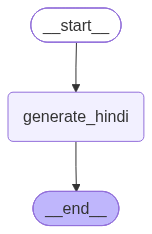

In [8]:
subgraph

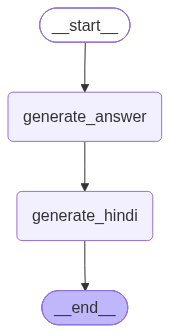

In [10]:
workflow

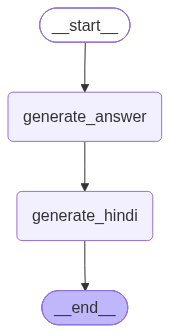

In [9]:
workflow